In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Load the data
file_path = '../Dataset/day_approach_maskedID_timeseries.csv'
df = pd.read_csv(file_path)

# Calculate Z1-2
# We assume Total KM is the sum of all intensities plus the aerobic base.
df['km Z1-2'] = df['total km'] - (df['km Z3-4'] + df['km Z5-T1-T2'] + df['km sprinting'])
df['km Z1-2'] = df['km Z1-2'].clip(lower=0)

# Separate the dataset into injury and no injury groups
injury_athletes = df[df['injury'] == 1]
no_injury_athletes = df[df['injury'] == 0]

# Take samples from the no injury group to balance the dataset
no_injury_sampled = no_injury_athletes.sample(n=len(injury_athletes), random_state=42)

# Combine the injury athletes with the sampled no injury athletes
balanced_df = pd.concat([injury_athletes, no_injury_sampled])

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selección de Variables Predictoras (X) y Objetivo (y)
# Quitamos columnas que son IDs, fechas o que contienen la respuesta
features = [
    'total km', 'km Z1-2', 'km Z3-4', 'km Z5-T1-T2', 'km sprinting', 
    'perceived exertion', 'perceived recovery', 'perceived trainingSuccess'
]

# Si creaste la columna 'km Z1-2' o 'efficiency_gap' en el EDA, ¡inclúyelas!
# features.append('efficiency_gap') 

X = balanced_df[features]
y = balanced_df['injury']

# 2. Limpieza rápida de NaNs (por si acaso los datos subjetivos tienen nulos)
X = X.fillna(X.mean())

# 3. División en entrenamiento y prueba (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Creación y entrenamiento del modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predicción
y_pred = model.predict(X_test)

Accuracy Score: 0.59

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.63      0.60       117
           1       0.59      0.54      0.57       117

    accuracy                           0.59       234
   macro avg       0.59      0.59      0.58       234
weighted avg       0.59      0.59      0.58       234



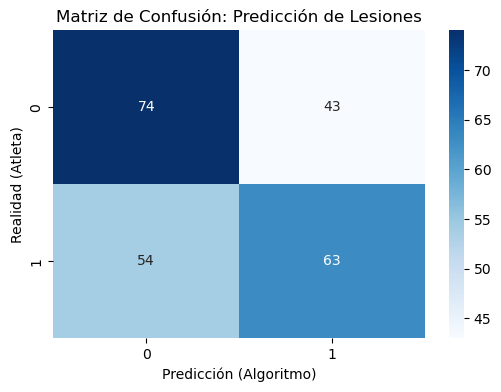

In [9]:
# 6. Métricas de rendimiento
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Matriz de Confusión (Visualización)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Predicción de Lesiones')
plt.xlabel('Predicción (Algoritmo)')
plt.ylabel('Realidad (Atleta)')
plt.show()

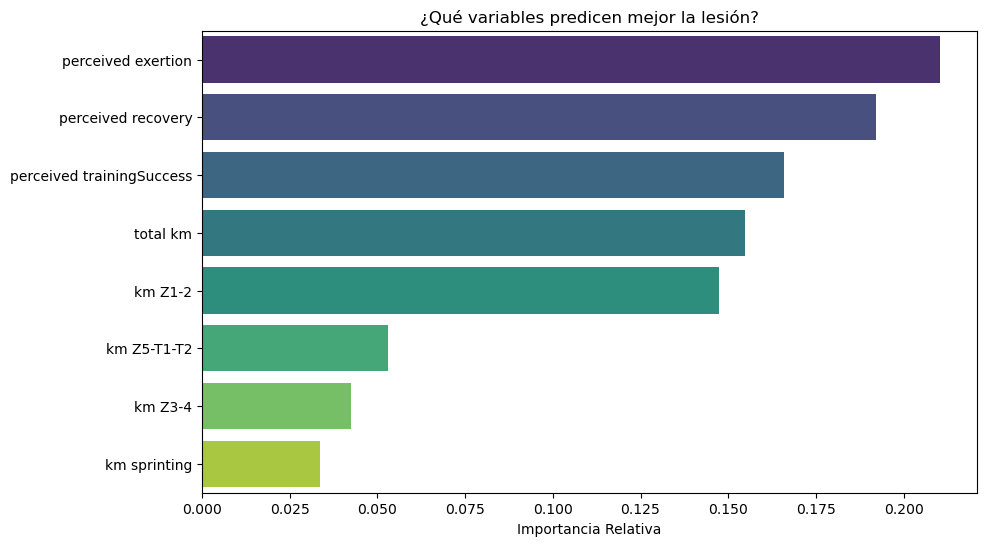

In [10]:
# 8. Gráfico de importancia de las variables
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('¿Qué variables predicen mejor la lesión?')
plt.xlabel('Importancia Relativa')
plt.show()

--- FINAL MODEL ACCURACY: 0.74 ---

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       117
           1       0.69      0.86      0.77       117

    accuracy                           0.74       234
   macro avg       0.75      0.74      0.73       234
weighted avg       0.75      0.74      0.73       234



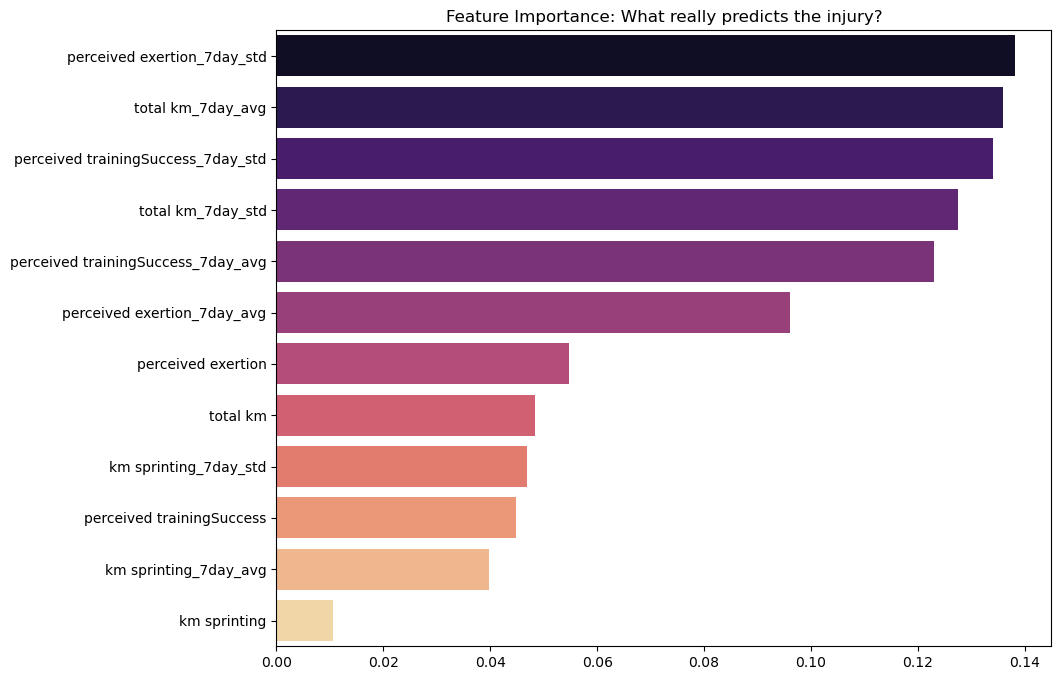

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. CARGA Y PREPROCESAMIENTO DE "MEMORIA" (FEATURE ENGINEERING)
file_path = '../Dataset/day_approach_maskedID_timeseries.csv'
df = pd.read_csv(file_path)

# Ordenamos por atleta y fecha para que el rolling tenga sentido fisiológico
# Nota: Si no tienes columna 'date', el rolling asume que las filas son consecutivas.
df_eng = df.copy()

# Definimos variables críticas para calcular su media semanal (Carga Aguda)
# Incluimos km y métricas percibidas (excluyendo el flag -0.01 en el cálculo si es posible)
features_to_roll = ['total km', 'km sprinting', 'perceived exertion', 'perceived trainingSuccess']

for col in features_to_roll:
    # Media móvil de 7 días: Representa la fatiga acumulada
    df_eng[f'{col}_7day_avg'] = df_eng.groupby('Athlete ID')[col].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
    # Desviación estándar de 7 días: Representa cambios bruscos o falta de rutina
    df_eng[f'{col}_7day_std'] = df_eng.groupby('Athlete ID')[col].transform(lambda x: x.rolling(window=7, min_periods=1).std())

# Limpieza de valores nulos generados por el rolling y ceros infinitos
df_eng = df_eng.fillna(0)

# 2. BALANCEO DEL DATASET (UNDER-SAMPLING)
# Ahora que tenemos mejores variables, balanceamos para entrenar
injury_data = df_eng[df_eng['injury'] == 1]
no_injury_data = df_eng[df_eng['injury'] == 0].sample(n=len(injury_data), random_state=42)

balanced_df = pd.concat([injury_data, no_injury_data])

# 3. SELECCIÓN DE FEATURES PARA EL MODELO
# Usamos las variables originales + las nuevas variables temporales
X_features = features_to_roll + [f'{c}_7day_avg' for c in features_to_roll] + [f'{c}_7day_std' for c in features_to_roll]
X = balanced_df[X_features]
y = balanced_df['injury']

# 4. ENTRENAMIENTO DEL MODELO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 5. EVALUACIÓN Y MÉTRICAS
y_pred = rf_model.predict(X_test)

print(f"--- FINAL MODEL ACCURACY: {accuracy_score(y_test, y_pred):.2f} ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. IMPORTANCIA DE VARIABLES (EL "PORQUÉ" BIOMÉDICO)
importances = pd.Series(rf_model.feature_importances_, index=X_features).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=importances, y=importances.index, palette='magma')
plt.title('Feature Importance: What really predicts the injury?')
plt.show()